# 03 — Baseline Model: Logistic Regression
A simple, interpretable benchmark. Every later model has to beat this.

**Key rule:** train and test sets are split **by patient**, so no patient appears in both.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
                             precision_recall_curve, confusion_matrix, classification_report)

PROC, FIG, RES = Path("data/processed"), Path("figures"), Path("results")
RES.mkdir(exist_ok=True)
df = pd.read_parquet(PROC / "model_table.parquet")
print(df.shape)

(99340, 42)


## 1. Patient-grouped train/test split (saved for every later step)

In [2]:
y = df["readmit_30"]
groups = df["patient_nbr"]
X = df.drop(columns=["readmit_30", "patient_nbr"])

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

pd.Series(groups.iloc[test_idx].unique(), name="patient_nbr").to_frame() \
  .to_parquet(PROC / "test_patients.parquet", index=False)

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
g_train = groups.iloc[train_idx]

overlap = set(groups.iloc[train_idx]) & set(groups.iloc[test_idx])
print(f"Train: {len(X_train):,}  Test: {len(X_test):,}  Patient overlap: {len(overlap)}")
print(f"Readmission rate  train {y_train.mean():.1%}  test {y_test.mean():.1%}")

Train: 79,567  Test: 19,773  Patient overlap: 0
Readmission rate  train 11.4%  test 11.3%


## 2. Pipeline: scale numbers, one-hot encode categories

In [3]:
cat_cols = X.select_dtypes("category").columns.tolist()
num_cols = X.select_dtypes("number").columns.tolist()

pre = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])
model = Pipeline([
    ("pre", pre),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced")),
])
print(f"{len(num_cols)} numeric, {len(cat_cols)} categorical features")

28 numeric, 12 categorical features


## 3. Cross-validation on the training set
5 folds, grouped by patient and stratified by outcome.
**PR-AUC** matters most here: with 11% positives, a random model scores about 0.11.

In [4]:
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_validate(model, X_train, y_train, groups=g_train, cv=cv,
                        scoring={"roc_auc": "roc_auc", "pr_auc": "average_precision"})
for m in ["roc_auc", "pr_auc"]:
    s = scores[f"test_{m}"]
    print(f"{m.upper():8s} {s.mean():.3f} ± {s.std():.3f}")

ROC_AUC  0.662 ± 0.004
PR_AUC   0.208 ± 0.008


## 4. Test-set performance

In [5]:
model.fit(X_train, y_train)
p_test = model.predict_proba(X_test)[:, 1]

roc = roc_auc_score(y_test, p_test)
pr  = average_precision_score(y_test, p_test)
prevalence = y_test.mean()

# capacity view: if a follow-up team can only call the top 10% riskiest patients
k = int(0.10 * len(p_test))
top = np.argsort(p_test)[::-1][:k]
precision_top10 = y_test.iloc[top].mean()
recall_top10 = y_test.iloc[top].sum() / y_test.sum()

print(f"ROC-AUC: {roc:.3f}")
print(f"PR-AUC:  {pr:.3f}   (random = {prevalence:.3f})")
print(f"Top 10% riskiest: precision {precision_top10:.1%}, catches {recall_top10:.1%} of all readmissions")
print("\nAt the default 0.5 threshold:")
print(classification_report(y_test, (p_test >= 0.5).astype(int), digits=3))

ROC-AUC: 0.671
PR-AUC:  0.219   (random = 0.113)
Top 10% riskiest: precision 25.6%, catches 22.5% of all readmissions

At the default 0.5 threshold:
              precision    recall  f1-score   support

           0      0.925     0.681     0.785     17529
           1      0.185     0.567     0.279      2244

    accuracy                          0.668     19773
   macro avg      0.555     0.624     0.532     19773
weighted avg      0.841     0.668     0.727     19773



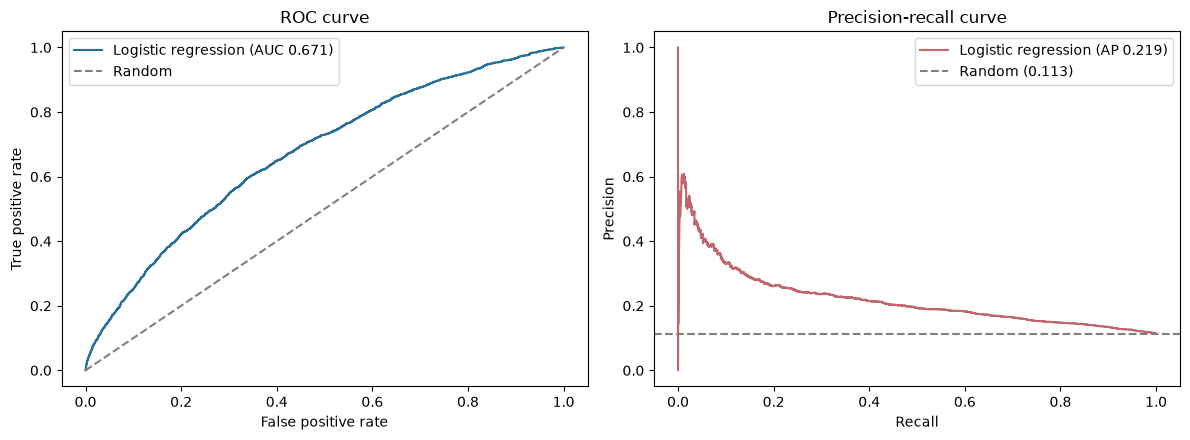

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fpr, tpr, _ = roc_curve(y_test, p_test)
axes[0].plot(fpr, tpr, color="#2a6f97", label=f"Logistic regression (AUC {roc:.3f})")
axes[0].plot([0, 1], [0, 1], "--", color="grey", label="Random")
axes[0].set(xlabel="False positive rate", ylabel="True positive rate", title="ROC curve")
axes[0].legend()

prec, rec, _ = precision_recall_curve(y_test, p_test)
axes[1].plot(rec, prec, color="#c1666b", label=f"Logistic regression (AP {pr:.3f})")
axes[1].axhline(prevalence, ls="--", color="grey", label=f"Random ({prevalence:.3f})")
axes[1].set(xlabel="Recall", ylabel="Precision", title="Precision-recall curve")
axes[1].legend()
plt.tight_layout()
plt.savefig(FIG / "03_baseline_curves.png", dpi=150)
plt.show()

## 5. What drives the model: largest coefficients

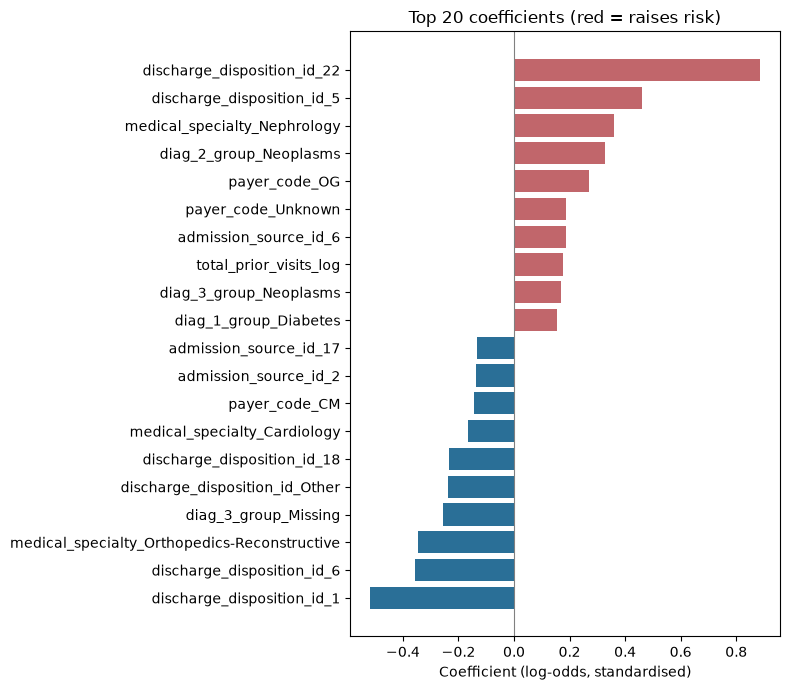

In [7]:
names = model.named_steps["pre"].get_feature_names_out()
coefs = pd.Series(model.named_steps["clf"].coef_[0], index=names)
top = pd.concat([coefs.nlargest(10), coefs.nsmallest(10)]).sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh([n.split("__", 1)[1] for n in top.index], top.values,
        color=["#c1666b" if v > 0 else "#2a6f97" for v in top.values])
ax.axvline(0, color="grey", lw=0.8)
ax.set_title("Top 20 coefficients (red = raises risk)")
ax.set_xlabel("Coefficient (log-odds, standardised)")
plt.tight_layout()
plt.savefig(FIG / "03_top_coefficients.png", dpi=150)
plt.show()

In [8]:
metrics = {"model": "logistic_regression",
           "cv_roc_auc": round(scores["test_roc_auc"].mean(), 4),
           "cv_pr_auc": round(scores["test_pr_auc"].mean(), 4),
           "test_roc_auc": round(roc, 4), "test_pr_auc": round(pr, 4),
           "test_precision_top10": round(precision_top10, 4),
           "test_recall_top10": round(recall_top10, 4)}
(RES / "03_baseline_metrics.json").write_text(json.dumps(metrics, indent=2))
metrics

{'model': 'logistic_regression',
 'cv_roc_auc': np.float64(0.6615),
 'cv_pr_auc': np.float64(0.2075),
 'test_roc_auc': 0.6714,
 'test_pr_auc': 0.2191,
 'test_precision_top10': np.float64(0.2559),
 'test_recall_top10': np.float64(0.2255)}

## 6. Summary
- **Test ROC-AUC / PR-AUC:** 0.671 / 0.219, against 0.113 for random guessing. Cross-validation (0.662 / 0.208, ±0.004) matches the test set, so the model is stable, not overfit.
- **Top 10% riskiest patients:** 25.6% are readmitted (2.3x the base rate), and this group contains 22.5% of all readmissions.
- **Strongest risk-raising features:** discharge to a rehab facility (disposition 22) or another inpatient institution (5); nephrology as the admitting specialty; neoplasms as a secondary diagnosis; diabetes as the primary diagnosis; and prior visits.
- **Strongest protective features:** discharge home (1) or home with home health (6), and orthopaedic or cardiology admissions.
- **Caveat:** prior-visit features appear weaker here than in the audit because the effect is split across several correlated versions (raw, log and total). LightGBM and SHAP will show their true weight.